## Imports and Functions

In [92]:
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt

from CSE583_humanSayMonkeyDo.core import (
    say_hello,
    get_nwbs,
    get_windowed_pos_chunk,
    get_chunk_spikes_binned_windowed,
    plot_firing_rate_heatmap,
    get_movement_onset_times,
    train_lda_classifier,
    plot_lda_results,
)


In [93]:

say_hello('hello')


'Hello, hello!'

## Using Data

In [94]:
#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
m_nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
m_nwbfile

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


In [95]:

#Get paths to human NWB files
human_paths = get_nwbs('human', 2)

#Load first NWB file
h_nwbfile = read_nwb(human_paths[0])
#Visualize entries
h_nwbfile

root pynwb.file.NWBFile at 0x13234591456
Fields:
  acquisition: {
    ElectricalSeries <class 'pynwb.ecephys.ElectricalSeries'>
  }
  devices: {
    auto_device <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    auto_group <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2019, 6, 19, 13, 7, 30, 430300, tzinfo=tzoffset(None, -25200))]
  identifier: GP33_B30
  institution: University of California, San Francisco
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    invalid_times <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  invalid_times: invalid_times <class 'pynwb.epoch.TimeIntervals'>
  lab: Chang Lab
  session_description: GP33_B30
  session_id: GP33_B30
  session_start_time: 1900-01-01 08:00:00+00:00
  subject: subject pynwb.file.Subject at 0x13234328720
Fields:
  species: Homo sapiens
  subject_id: GP33

  timestamps_reference_time: 1900-01-01 08:00:00+00:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>

In [96]:
#def get_kinematics(nwbfile):
#    if nwbfile.
def timestamps_to_binary(timestamps, start_stop_times):
    """
    Convert timestamps to binary time series based on start/stop intervals.
    
    Parameters
    ----------
    timestamps : array-like
        Array of timestamps to evaluate.
    start_stop_times : array-like
        2D array of shape (n, 2) where each row contains [start_time, stop_time].
        The first column contains start times, the second column contains stop times.
    
    Returns
    -------
    numpy.ndarray
        Binary array of shape (len(timestamps),) where 1 indicates the timestamp
        falls within at least one start/stop interval, and 0 indicates it falls
        outside all intervals.
    
    Raises
    ------
    ValueError
        If start_stop_times is not a 2D array with 2 columns.
        If any stop time is less than its corresponding start time.
    
    Examples
    --------
    >>> timestamps = np.array([0, 1, 2, 3, 4, 5])
    >>> start_stop = np.array([[1, 3], [4, 5]])
    >>> timestamps_to_binary(timestamps, start_stop)
    array([0, 1, 1, 1, 1, 1])
    
    >>> timestamps = np.array([0.5, 1.5, 2.5, 3.5])
    >>> start_stop = np.array([[1.0, 2.0]])
    >>> timestamps_to_binary(timestamps, start_stop)
    array([0, 1, 0, 0])
    
    Notes
    -----
    If intervals overlap, timestamps within overlapping regions are still marked
    as 1 (within interval). The function uses vectorized operations for efficiency.
    Interval boundaries are inclusive: timestamps equal to start or stop times
    are considered within the interval.
    """
    import numpy as np
    
    timestamps = np.asarray(timestamps)
    start_stop_times = np.asarray(start_stop_times)
    
    # Validate input shape
    if start_stop_times.ndim != 2 or start_stop_times.shape[1] != 2:
        raise ValueError(
            "start_stop_times must be a 2D array with 2 columns "
            f"(start, stop), got shape {start_stop_times.shape}"
        )
    
    # Validate start <= stop for all pairs
    if np.any(start_stop_times[:, 1] < start_stop_times[:, 0]):
        raise ValueError("All stop times must be >= their corresponding start times")
    
    # Initialize binary array
    binary_series = np.zeros(len(timestamps), dtype=int)
    
    # Check each interval
    for start, stop in start_stop_times:
        # Mark timestamps within this interval as 1
        within_interval = (timestamps >= start) & (timestamps <= stop)
        binary_series = np.logical_or(binary_series, within_interval).astype(int)
    
    return binary_series

def samples_to_timeseries(n_samples, fs):
    """
    Convert number of samples and sampling frequency to a time series.
    
    Parameters
    ----------
    n_samples : int
        Number of samples in the time series.
    fs : float
        Sampling frequency in Hz.
    
    Returns
    -------
    numpy.ndarray
        Array of time values starting at 0, with shape (n_samples,).
    
    Raises
    ------
    ValueError
        If n_samples is not positive or fs is not positive.
    
    Examples
    --------
    >>> samples_to_timeseries(5, 100)
    array([0.  , 0.01, 0.02, 0.03, 0.04])
    
    >>> samples_to_timeseries(10, 1000)
    array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009])
    
    Notes
    -----
    The time series is generated using numpy.arange with a step size of 1/fs.
    The resulting array will have exactly n_samples elements.
    """
    import numpy as np
    
    if n_samples <= 0:
        raise ValueError("n_samples must be positive")
    if fs <= 0:
        raise ValueError("fs must be positive")
    
    return np.arange(n_samples) / fs

def get_monkey_kinematics(nwbfile):
    """
    Extract cursor position kinematics from monkey NWB file.
    
    This function retrieves the x/y cursor position data from a monkey
    performing a cursor control task. The cursor position represents the
    location on screen controlled by the animal's arm movements over time.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing behavioral data from monkey experiments.
        Must contain:
        - processing['behavior'].data_interfaces['Position']: Position data
        - spatial_series['cursor_pos']: Cursor position time series with
          .data and .timestamps attributes
    
    Returns
    -------
    kinematic : numpy.ndarray
        Array of shape (n_samples, 2) containing x/y cursor positions on screen.
        Each row represents [x_position, y_position] at a given time point.
    timestamps : numpy.ndarray
        Array of shape (n_samples,) containing the timestamp for each cursor
        position sample.
    
    Raises
    ------
    KeyError
        If 'behavior' processing module, 'Position' interface, or 'cursor_pos'
        spatial series is not found in the NWB file.
    AttributeError
        If required .data or .timestamps attributes are missing.
    
    Examples
    --------
    >>> kinematic, timestamps = get_monkey_kinematics(nwbfile)
    >>> print(f"Cursor data shape: {kinematic.shape}")
    >>> print(f"Recording duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
    >>> print(f"X range: [{kinematic[:, 0].min()}, {kinematic[:, 0].max()}]")
    
    Notes
    -----
    The cursor position data represents screen coordinates controlled by the
    monkey's arm movements during behavioral tasks. Timestamps are stored
    separately and may not be uniformly sampled.
    """
    cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
    kinematic = cursor_pos.data[:]
    timestamps = cursor_pos.timestamps[:]
    
    return kinematic, timestamps

def get_human_kinematics(nwbfile):
    """
    Extract binary speaking activity time series from NWB file.
    
    This function creates a binary time series indicating when a human subject
    was actively speaking during ECoG recordings. Speaking periods are derived
    from trial metadata in the NWB file.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing ECoG data and trial information.
        Must contain:
        - acquisition['ElectricalSeries']: ECoG recordings with .data and .rate
        - trials: DataFrame with 'speak', 'start_time', and 'stop_time' columns
    
    Returns
    -------
    binary_kinematic : numpy.ndarray
        Binary array of shape (n_samples,) where 1 indicates the subject was
        speaking and 0 indicates the subject was not speaking.
    timestamps : numpy.ndarray
        Array of timestamps corresponding to each sample in binary_kinematic,
        starting at 0 and sampled at the ECoG sampling rate.
    
    Raises
    ------
    KeyError
        If 'ElectricalSeries' is not found in nwbfile.acquisition.
    AttributeError
        If required fields are missing from the NWB file structure.
    ValueError
        If no speaking trials are found (all speak==False).
    
    Examples
    --------
    >>> binary_kin, times = get_human_kinematics(nwbfile)
    >>> print(f"Total samples: {len(binary_kin)}")
    >>> print(f"Speaking samples: {np.sum(binary_kin)}")
    >>> print(f"Duration: {times[-1]:.2f} seconds")
    
    Notes
    -----
    The function filters trials to include only those where speak==True,
    then marks all timestamps falling within those trial periods as speaking (1).
    All other timestamps are marked as non-speaking (0).
    """
    total_samples = nwbfile.acquisition['ElectricalSeries'].data.shape[0]
    fs = nwbfile.acquisition['ElectricalSeries'].rate
    timestamps = samples_to_timeseries(total_samples, fs)
    
    data = nwbfile.trials[:]
    remove_non_speaking = data['speak'] == True
    data = data[remove_non_speaking]
    
    start_stop_times = np.array(data[["start_time", "stop_time"]])
    binary_kinematic = timestamps_to_binary(timestamps, start_stop_times)
    
    return binary_kinematic, timestamps

def get_kinematics(nwbfile):
    """
    Extract kinematic data from NWB file based on subject species.
    
    This function routes to species-specific kinematic extraction methods
    and returns kinematic data along with metadata describing the data type
    and subject species.
    
    Parameters
    ----------
    nwbfile : pynwb.NWBFile
        NWB file object containing subject information and kinematic data.
        Must have nwbfile.subject.species set to either 'Macaca mulatta'
        or 'Homo sapiens'.
    
    Returns
    -------
    kinematic : numpy.ndarray
        Kinematic data array. Shape and content depend on species:
        - Macaca mulatta: (n_samples, 2) array of x/y cursor positions
        - Homo sapiens: (n_samples,) binary array of speaking activity
    timestamps : numpy.ndarray
        Array of shape (n_samples,) containing timestamps for each sample.
    metadata : dict
        Dictionary containing kinematic metadata with keys:
        - 'species': Subject species name
        - 'kinematic_type': Type of kinematic data ('cursor_position' or 'speech_binary')
    
    Raises
    ------
    ValueError
        If subject species is neither 'Macaca mulatta' nor 'Homo sapiens'.
    AttributeError
        If nwbfile.subject.species is not accessible.
    
    Examples
    --------
    >>> kinematic, timestamps, metadata = get_kinematics(nwbfile)
    >>> print(f"Species: {metadata['species']}")
    >>> print(f"Kinematic type: {metadata['kinematic_type']}")
    >>> print(f"Data shape: {kinematic.shape}")
    
    Notes
    -----
    This function serves as a unified interface for extracting kinematic data
    from both monkey cursor control experiments and human speech experiments.
    The metadata dictionary allows downstream code to properly interpret the
    kinematic data based on its type and source species.
    """
    if nwbfile.subject.species == 'Macaca mulatta':
        kinematic, timestamps = get_monkey_kinematics(nwbfile)
        metadata = {
            'species': 'Macaca mulatta',
            'kinematic_type': 'cursor_position'
        }
    elif nwbfile.subject.species == 'Homo sapiens':
        kinematic, timestamps = get_human_kinematics(nwbfile)
        metadata = {
            'species': 'Homo sapiens',
            'kinematic_type': 'speech_binary'
        }
    else:
        raise ValueError("Missing required field: NWB file does not have monkey or human species")
    
    return kinematic, timestamps, metadata

In [98]:
kinematics, timestamps, metadata = get_kinematics(h_nwbfile)

In [ ]:
def get_trial_times(nwbfile):
    if nwbfile.subject.species == 'Macaca mulatta':
        kinematic, timestamps = get_monkey_trial_times(nwbfile)
        metadata = {
            'species': 'Macaca mulatta',
            'kinematic_type': 'cursor_position'
            }
    elif nwbfile.subject.species == 'Homo sapiens':
        kinematic, timestamps = get_human_trial_times(nwbfile)
            metadata = {
            'species': 'Homo sapiens',
            'kinematic_type': 'speech_binary'
            }
    else:
        raise ValueError("Missing required field: NWB file does not have monkey or human species")

# Lets view the data stored in the NWB file

cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = nwbfile.trials['go_cue_time'].data[:]
go_cue_times = go_cue_times[~np.isnan(go_cue_times)]  # Remove NaN values if any
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(cursor_pos, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])

In [5]:
list_units_spkts = nwbfile.units[:]['spike_times']

(220, 18, 71)
(18, 71)


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

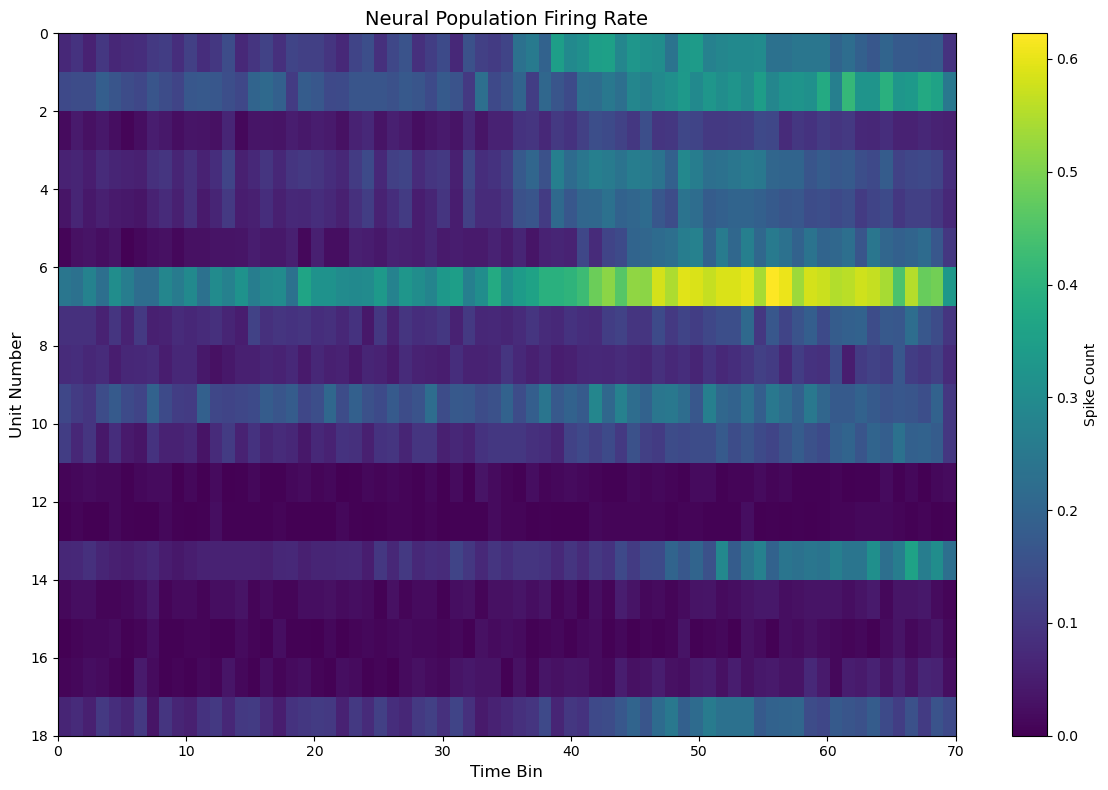

In [6]:
spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times, window, bin_size=0.01)
print(spike_data[0].shape)
avg_spike_rates = np.mean(spike_data[0],axis=0)
print(avg_spike_rates.shape)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

In [7]:

cursor_vel = nwbfile.processing['behavior'].data_interfaces['Velocity'].time_series['cursor_vel']

# Usage
movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

# Filter out trials with no movement detected
valid_trials = ~np.isnan(movement_times)
print(f"Movement detected in {valid_trials.sum()}/{len(go_cue_times)} trials")
print(f"First movement onset at: {movement_times[valid_trials][0]:.3f} seconds")



Movement detected in 220/220 trials
First movement onset at: 5.930 seconds


In [ ]:
window = [0.0, 0.2]
movement_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, movement_times[valid_trials], window, bin_size=0.01)



window = [0.2, 0.0]
stationary_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times[valid_trials], window, bin_size=0.01)

data = movement_spike_data[0]
move_category = np.ones(movement_spike_data[0].shape[0], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data[0]], axis=0)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data[0].shape[0], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)



(440,)
(440, 18, 21)


Data shape: (440, 378)
Labels shape: (440,)
Class distribution: 0=220, 1=220

=== LDA Classification Results ===
Training Accuracy: 1.000
Test Accuracy: 0.591
Cross-validation Accuracy: 0.595 (+/- 0.076)

CV Scores: [0.47727273 0.56818182 0.57954545 0.69318182 0.65909091]

=== Test Set Confusion Matrix ===
[[29 15]
 [21 23]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.58      0.66      0.62        44
     Class 1       0.61      0.52      0.56        44

    accuracy                           0.59        88
   macro avg       0.59      0.59      0.59        88
weighted avg       0.59      0.59      0.59        88



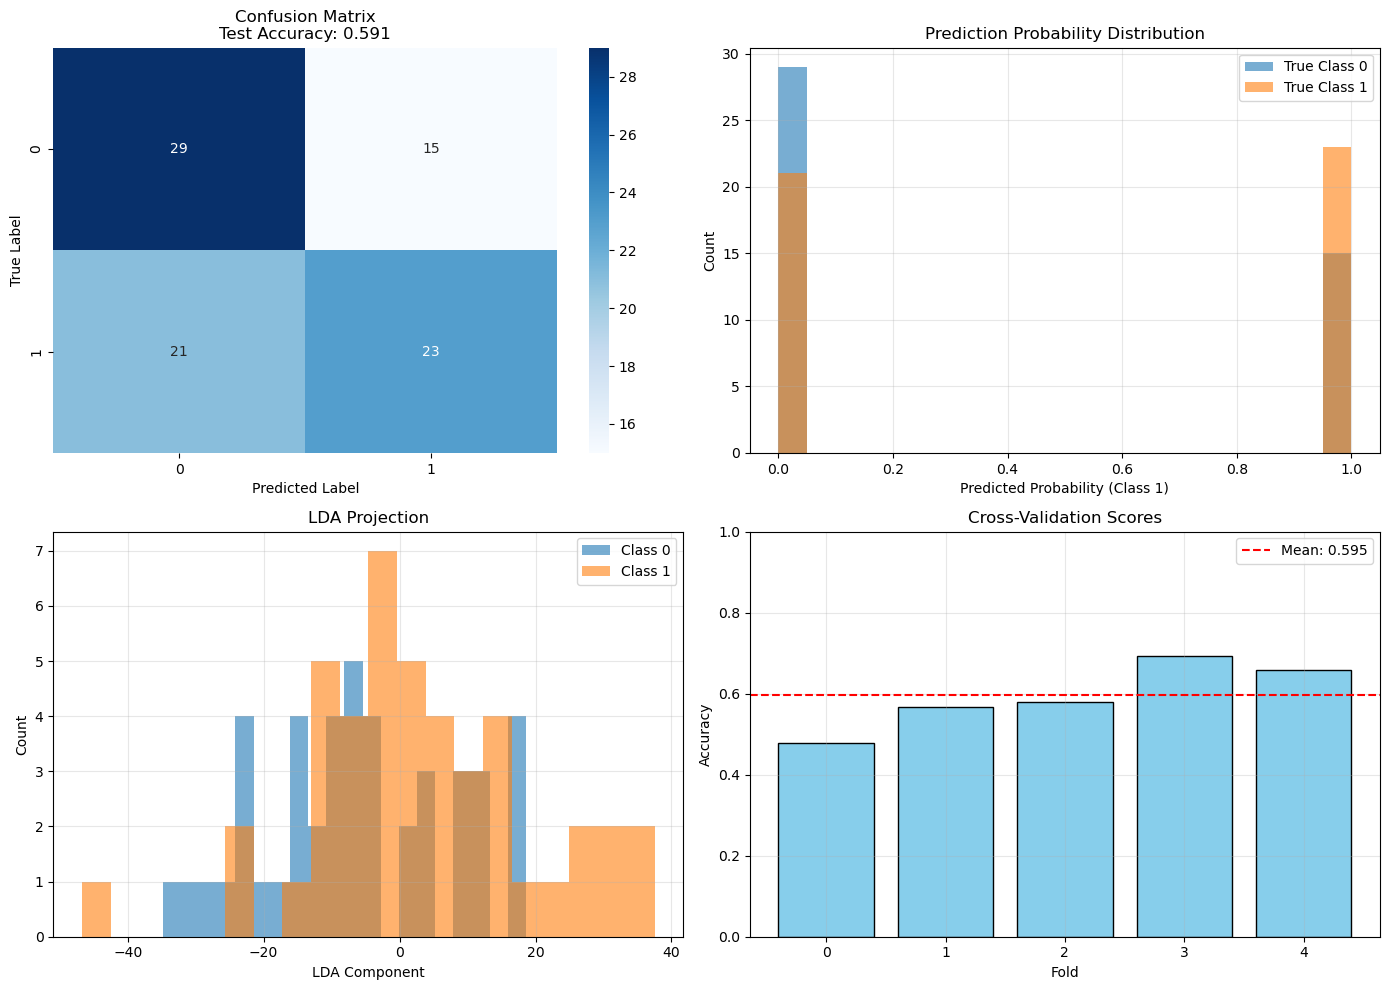

In [ ]:



# Assuming you have:
# moving_spike_data: list of [18, 21] matrices for moving trials
# stationary_spike_data: list of [18, 21] matrices for stationary trials

# Combine data and create labels
#data_matrices = moving_spike_data + stationary_spike_data
#labels = np.concatenate([
#    np.ones(len(moving_spike_data), dtype=int),   # 1 for moving
#    np.zeros(len(stationary_spike_data), dtype=int)  # 0 for stationary
#])

# Train classifier
lda, results = train_lda_classifier(data, move_category)

# Visualize
plot_lda_results(results)